What is a UMAP

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import drive
drive.mount('/content/drive/')

path = '/content/drive/MyDrive/Simple GAN/'

Mounted at /content/drive/


In [ ]:
fake = pd.read_csv(path + 'Generated_Cancer_transformed.csv')
real = pd.read_csv(path + 'Cancer_Transformed.csv')

In [ ]:
real[7] = np.ones(len(real))
fake[7] = np.zeros(len(fake))

In [ ]:
join = pd.concat([real, fake], axis=0, ignore_index=True)

In [ ]:
join

,0,1,2,3,4,5,6,7
0,2.532475,2.489734,1.886690,-1.359293,1.307686,2.296076,2.750622,1.0
1,0.548144,0.499255,1.805927,-0.369203,-0.375612,1.087084,-0.243890,1.0
2,2.037231,1.228676,1.511870,-0.023974,0.527407,1.955000,1.152255,1.0
3,1.451707,0.326373,-0.281464,0.133984,3.394275,2.175786,6.046041,1.0
4,1.428493,1.270543,1.298575,-1.466770,0.220556,0.729259,-0.868353,1.0
...,...,...,...,...,...,...,...,...
1164,-0.865698,-0.209981,-0.229982,-0.299046,-0.785230,-1.147941,-1.168096,0.0
1165,-0.843040,-0.260647,-0.168185,-0.181143,-0.776073,-1.106847,-1.312580,0.0
1166,-0.746396,-0.257897,-0.118396,-0.169688,-0.642103,-0.917253,-1.207667,0.0
1167,-0.642248,-0.276989,-0.161437,-0.114484,-0.511912,-0.787181,-0.900384,0.0


In [ ]:
join.iloc[:, :-1]

,0,1,2,3,4,5,6
0,2.532475,2.489734,1.886690,-1.359293,1.307686,2.296076,2.750622
1,0.548144,0.499255,1.805927,-0.369203,-0.375612,1.087084,-0.243890
2,2.037231,1.228676,1.511870,-0.023974,0.527407,1.955000,1.152255
3,1.451707,0.326373,-0.281464,0.133984,3.394275,2.175786,6.046041
4,1.428493,1.270543,1.298575,-1.466770,0.220556,0.729259,-0.868353
...,...,...,...,...,...,...,...
1164,-0.865698,-0.209981,-0.229982,-0.299046,-0.785230,-1.147941,-1.168096
1165,-0.843040,-0.260647,-0.168185,-0.181143,-0.776073,-1.106847,-1.312580
1166,-0.746396,-0.257897,-0.118396,-0.169688,-0.642103,-0.917253,-1.207667
1167,-0.642248,-0.276989,-0.161437,-0.114484,-0.511912,-0.787181,-0.900384


In [ ]:
def run_umap(X, y, n_neighbors=15, min_dist=0.1, random_state=42):
    from sklearn.preprocessing import StandardScaler
    import umap
    import matplotlib.pyplot as plt

    # Scale features
    X_scaled = StandardScaler().fit_transform(X)

    # UMAP -> 2D
    reducer = umap.UMAP(
        n_neighbors=n_neighbors,
        min_dist=min_dist,
        n_components=2,
        random_state=random_state
    )
    X_umap = reducer.fit_transform(X_scaled)

    # Plot
    plt.figure(figsize=(7, 6))
    plt.scatter(X_umap[:, 0], X_umap[:, 1], c=y, s=8)
    plt.title("UMAP (2D)")
    plt.xlabel("UMAP-1")
    plt.ylabel("UMAP-2")
    plt.show()

    return X_umap

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


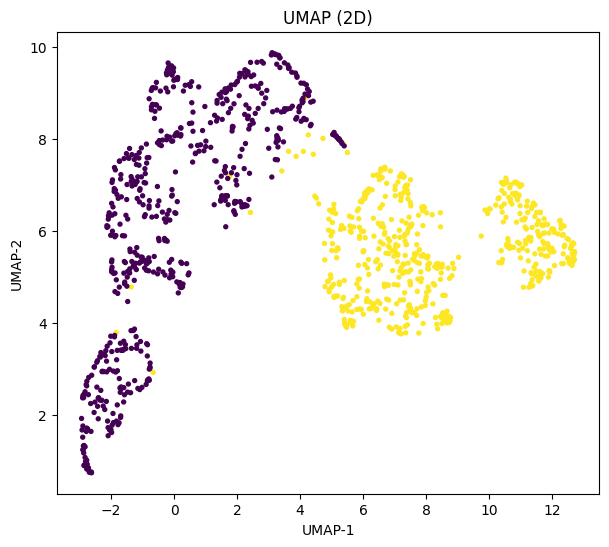

In [ ]:
# pip install umap-learn matplotlib scikit-learn

import umap
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.preprocessing import StandardScaler

# Example data (replace with your X, y)
X, y = join.iloc[:, :-1], join.iloc[:, -1]

# (Optional but recommended) scale features
X_scaled = StandardScaler().fit_transform(X)

# UMAP -> 2D
reducer = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    n_components=2,
    random_state=42
)
X_umap = reducer.fit_transform(X_scaled)

# Plot
plt.figure(figsize=(7, 6))
plt.scatter(X_umap[:, 0], X_umap[:, 1], c=y, s=8)
plt.title("UMAP (2D)")
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.show()


In [ ]:
## Best Result on Vanilla GAN so far

In [ ]:
minmax_real = pd.read_csv(path + 'Generated_Cancer_minmax.csv')
minmax_fake = pd.read_csv(path + 'Cancer_minmax.csv')

minmax_real[7] = np.ones(len(minmax_real))
minmax_fake[7] = np.zeros(len(minmax_fake))

In [ ]:
join = pd.concat([minmax_real, minmax_fake], axis=0, ignore_index=True)
X, y = join.iloc[:, :-1], join.iloc[:, -1]

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


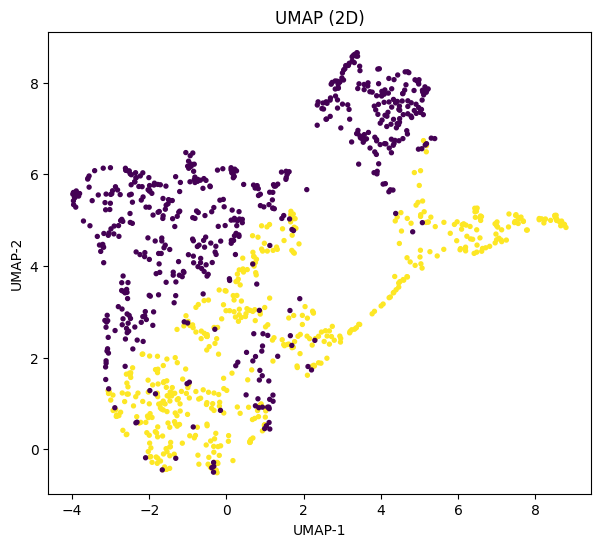

In [ ]:
run_map = run_umap(X, y)

In [ ]:
def run_umap(X, y, n_neighbors=15, min_dist=0.1, random_state=42):
    from sklearn.preprocessing import StandardScaler
    import umap
    import matplotlib.pyplot as plt

    # Scale features
    X_scaled = StandardScaler().fit_transform(X)

    # UMAP -> 2D
    reducer = umap.UMAP(
        n_neighbors=n_neighbors,
        min_dist=min_dist,
        n_components=2,
        random_state=random_state
    )
    X_umap = reducer.fit_transform(X_scaled)

    # Plot
    plt.figure(figsize=(7, 6))
    plt.scatter(X_umap[:, 0], X_umap[:, 1], c=y, s=8)
    plt.title("UMAP (2D)")
    plt.xlabel("UMAP-1")
    plt.ylabel("UMAP-2")
    plt.show()

    return X_umap